# 🔬 Advanced Feature Engineering

Este notebook explora **feature engineering avançado** para melhorar a performance dos modelos.

## 📋 Conteúdo

1. **Feature Selection Automático**
   - Mutual Information
   - SHAP values
   - Correlation analysis

2. **Features Meteorológicas Derivadas**
   - Heat Index (índice de calor)
   - Wind Chill (sensação térmica)
   - Dew Point (ponto de orvalho)
   - Comfort Index

3. **Features de Tendência**
   - Diferenças temporais
   - Taxas de variação
   - Momentum

4. **Polynomial Interactions**
   - Interações de 2ª ordem
   - Features não-lineares

5. **Comparação de Performance**
   - Modelo baseline vs avançado

## 1. Setup

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings
from datetime import datetime

from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

from src.features.feature_engineering import FeatureEngineer
from src.models.evaluation import ModelEvaluator

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ Bibliotecas carregadas")
print(f"Início: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ Bibliotecas carregadas
Início: 2025-10-07 10:43:36


## 2. Carregar Dados

In [2]:
# Carregar dados processados
df = pd.read_parquet('../data/processed/processed_data.parquet')

print(f"Dados carregados: {len(df):,} linhas")
print(f"Período: {df['timestamp'].min()} a {df['timestamp'].max()}")
print(f"Regiões: {', '.join(df['region'].unique())}")
print(f"\nColunas disponíveis: {list(df.columns)}")

Dados carregados: 175,205 linhas
Período: 2021-01-01 00:00:00 a 2024-12-31 00:00:00
Regiões: Alentejo, Algarve, Centro, Lisboa, Norte

Colunas disponíveis: ['timestamp', 'region', 'consumption_mw', 'city', 'latitude', 'longitude', 'temperature', 'temperature_feels_like', 'humidity', 'wind_speed', 'precipitation', 'cloud_cover', 'pressure', 'date', 'is_holiday', 'is_holiday_eve', 'is_holiday_after', 'days_to_holiday', 'days_from_holiday', 'holiday_name', 'hour', 'day_of_week', 'day_of_month', 'month', 'quarter', 'day_of_year', 'week_of_year', 'is_weekend', 'is_business_hour', 'sin_hour', 'cos_hour', 'sin_day_of_week', 'cos_day_of_week', 'sin_month', 'cos_month', 'sin_day_of_year', 'cos_day_of_year']


## 3. Features Meteorológicas Derivadas

Vamos criar features baseadas em fórmulas meteorológicas conhecidas.

In [3]:
def create_weather_derived_features(df):
    """
    Cria features meteorológicas derivadas
    """
    df = df.copy()
    
    # 1. Heat Index (índice de calor) - quando T > 27°C e humidade > 40%
    # Simplificado: HI = c1 + c2*T + c3*RH + c4*T*RH
    T = df['temperature']
    RH = df['humidity']
    
    df['heat_index'] = (
        -8.78469475556 + 
        1.61139411 * T + 
        2.33854883889 * RH + 
        -0.14611605 * T * RH
    )
    
    # 2. Wind Chill (sensação térmica com vento) - quando T < 10°C
    V = df['wind_speed']
    df['wind_chill'] = (
        13.12 + 0.6215 * T - 11.37 * (V ** 0.16) + 0.3965 * T * (V ** 0.16)
    )
    
    # 3. Dew Point (ponto de orvalho) - aproximação
    df['dew_point'] = T - ((100 - RH) / 5)
    
    # 4. Comfort Index (índice de conforto) - combinação de temperatura e humidade
    df['comfort_index'] = T - (0.55 - 0.0055 * RH) * (T - 14.5)
    
    # 5. Temperatura efetiva (com vento e humidade)
    df['effective_temperature'] = T - 0.4 * (T - 10) * (1 - RH / 100)
    
    # 6. Pressão relativa (diferença da média)
    df['pressure_relative'] = df['pressure'] - df['pressure'].mean()
    
    # 7. Índice de precipitação ponderado por temperatura
    df['precip_temp_index'] = df['precipitation'] * (1 + df['temperature'] / 100)
    
    # 8. Cobertura de nuvens vs radiação solar (inverso)
    df['solar_proxy'] = 100 - df['cloud_cover']  # Proxy para radiação solar
    
    # 9. Razões meteorológicas
    df['temp_humidity_ratio'] = T / (RH + 1)  # +1 para evitar divisão por zero
    df['wind_precip_ratio'] = V / (df['precipitation'] + 0.1)
    
    print(f"✓ Criadas {9} features meteorológicas derivadas")
    return df

# Aplicar
df_weather = create_weather_derived_features(df)

# Visualizar algumas
print("\nNovos features criados:")
new_features = ['heat_index', 'wind_chill', 'dew_point', 'comfort_index', 
                'effective_temperature', 'solar_proxy']
print(df_weather[new_features].describe())

✓ Criadas 9 features meteorológicas derivadas

Novos features criados:
          heat_index     wind_chill      dew_point  comfort_index  \
count  175205.000000  175205.000000  175205.000000  175205.000000   
mean       19.356871      17.123580      10.998054      16.176787   
std        54.738935       7.604352       4.273041       5.189281   
min      -107.944843      -4.150662      -3.797467       0.109700   
25%       -26.021317      10.934598       7.680839      12.105436   
50%         8.632623      17.214916      11.003251      16.576004   
75%        58.775085      23.302747      14.301140      20.507761   
max       223.644062      37.377457      24.774481      28.449084   

       effective_temperature    solar_proxy  
count          175205.000000  175205.000000  
mean               15.861395      41.260814  
std                 5.301993      21.488147  
min                 0.008337       0.000000  
25%                11.643138      26.409870  
50%                16.145812   

## 4. Feature Engineering Completo (com lags)

In [4]:
# Aplicar feature engineering base
fe = FeatureEngineer()
df_features = fe.create_all_features(df_weather)

print(f"\nFeatures após FE básico: {df_features.shape[1]} colunas")
print(f"Amostras retidas: {len(df_features):,} ({len(df_features)/len(df)*100:.1f}%)")

Creating features...
  - Temporal features
  - Lag features
  - Rolling features
  - Interaction features
  - Removed 240 rows with NaN

Features após FE básico: 83 colunas
Amostras retidas: 174,965 (99.9%)


## 5. Features de Tendência e Variação

In [5]:
def create_trend_features(df):
    """
    Cria features de tendência e variação
    """
    df = df.copy()
    
    # Processar por região
    dfs_by_region = []
    for region in df['region'].unique():
        df_region = df[df['region'] == region].copy().sort_values('timestamp')
        
        # 1. Diferenças de primeira ordem (variação)
        df_region['temp_diff_1h'] = df_region['temperature'].diff(1)
        df_region['humidity_diff_1h'] = df_region['humidity'].diff(1)
        df_region['wind_diff_1h'] = df_region['wind_speed'].diff(1)
        df_region['pressure_diff_1h'] = df_region['pressure'].diff(1)
        
        # 2. Diferenças de segunda ordem (aceleração)
        df_region['temp_diff2_1h'] = df_region['temp_diff_1h'].diff(1)
        
        # 3. Momentum (taxa de variação em %)
        df_region['temp_momentum'] = df_region['temperature'].pct_change(periods=3) * 100
        df_region['wind_momentum'] = df_region['wind_speed'].pct_change(periods=3) * 100
        
        # 4. Desvio da média móvel (anomalia)
        df_region['temp_deviation_24h'] = (
            df_region['temperature'] - df_region['temperature'].rolling(24, min_periods=1).mean()
        )
        
        # 5. Volatilidade (std móvel)
        df_region['temp_volatility_12h'] = df_region['temperature'].rolling(12, min_periods=1).std()
        df_region['wind_volatility_12h'] = df_region['wind_speed'].rolling(12, min_periods=1).std()
        
        dfs_by_region.append(df_region)
    
    df_result = pd.concat(dfs_by_region, ignore_index=True)
    df_result = df_result.sort_values('timestamp').reset_index(drop=True)
    
    print(f"✓ Criadas features de tendência e variação")
    return df_result

# Aplicar
df_features = create_trend_features(df_features)

print(f"\nTotal de features agora: {df_features.shape[1]} colunas")

✓ Criadas features de tendência e variação

Total de features agora: 93 colunas


## 6. Análise de Correlação e Feature Selection

In [6]:
# Preparar dados para análise
exclude_cols = ['timestamp', 'region', 'holiday_name', 'consumption_mw']
feature_cols = [c for c in df_features.columns if c not in exclude_cols]
feature_cols = [c for c in feature_cols if not pd.api.types.is_datetime64_any_dtype(df_features[c])]
feature_cols = [c for c in feature_cols if df_features[c].dtype != 'object']

# Remover NaN
df_clean = df_features[feature_cols + ['consumption_mw']].dropna()

print(f"Features para análise: {len(feature_cols)}")
print(f"Amostras: {len(df_clean):,}")

Features para análise: 87
Amostras: 174,950



CORRELAÇÃO COM TARGET (consumption_mw)

Top 20 features mais correlacionadas:
consumption_mw_rolling_mean_3     0.989978
consumption_mw_rolling_min_3      0.989970
consumption_mw_rolling_max_3      0.984992
consumption_mw_lag_1              0.984135
consumption_mw_lag_24             0.971675
consumption_mw_rolling_min_6      0.969063
consumption_mw_lag_2              0.963049
consumption_mw_rolling_mean_6     0.958496
consumption_mw_lag_48             0.953167
consumption_mw_rolling_max_6      0.937858
consumption_mw_lag_3              0.931348
consumption_mw_rolling_min_12     0.909991
consumption_mw_rolling_mean_24    0.905233
consumption_mw_rolling_max_24     0.903889
consumption_mw_rolling_mean_48    0.898044
consumption_mw_rolling_max_48     0.896720
consumption_mw_rolling_mean_12    0.891288
longitude                         0.884921
consumption_mw_rolling_std_24     0.884258
consumption_mw_rolling_std_48     0.883282
dtype: float64


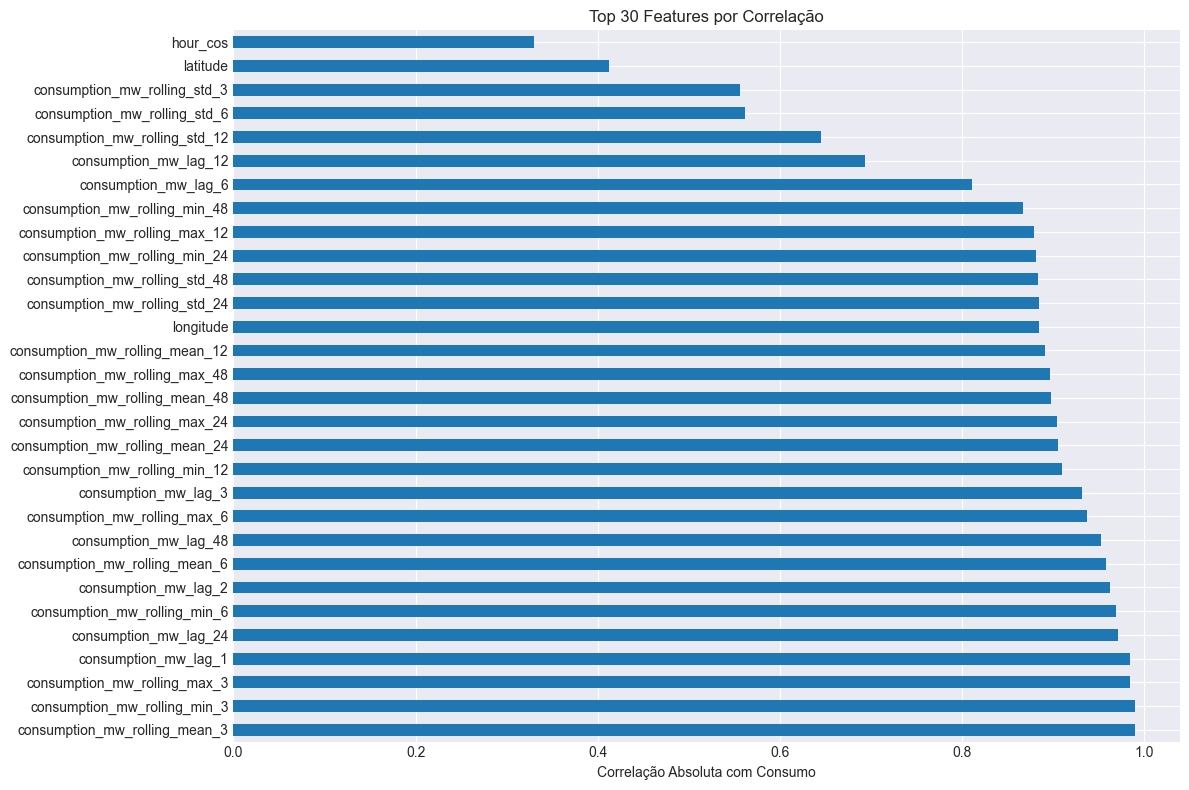

In [7]:
# 1. CORRELAÇÃO COM TARGET
print("\n" + "="*80)
print("CORRELAÇÃO COM TARGET (consumption_mw)")
print("="*80)

correlations = df_clean[feature_cols].corrwith(df_clean['consumption_mw']).abs().sort_values(ascending=False)

print("\nTop 20 features mais correlacionadas:")
print(correlations.head(20))

# Visualizar
fig, ax = plt.subplots(figsize=(12, 8))
correlations.head(30).plot(kind='barh', ax=ax)
ax.set_xlabel('Correlação Absoluta com Consumo')
ax.set_title('Top 30 Features por Correlação')
plt.tight_layout()
plt.show()


MUTUAL INFORMATION ANALYSIS
Calculando... (pode demorar alguns minutos)

Top 20 features por Mutual Information:
consumption_mw_rolling_max_3      4.428181
consumption_mw_rolling_min_3      3.780568
consumption_mw_rolling_max_6      3.712435
consumption_mw_rolling_min_6      2.926364
consumption_mw_rolling_max_12     2.595101
consumption_mw_rolling_min_12     2.069682
consumption_mw_rolling_mean_3     2.030023
consumption_mw_lag_1              1.754541
consumption_mw_rolling_mean_6     1.545816
consumption_mw_lag_24             1.486856
consumption_mw_lag_2              1.407434
consumption_mw_lag_48             1.235756
consumption_mw_lag_3              1.223733
consumption_mw_rolling_mean_12    1.204584
consumption_mw_rolling_max_24     1.168958
consumption_mw_rolling_min_24     1.047236
consumption_mw_rolling_max_48     1.032792
consumption_mw_rolling_mean_24    1.013846
consumption_mw_lag_6              0.970392
consumption_mw_rolling_mean_48    0.949702
dtype: float64


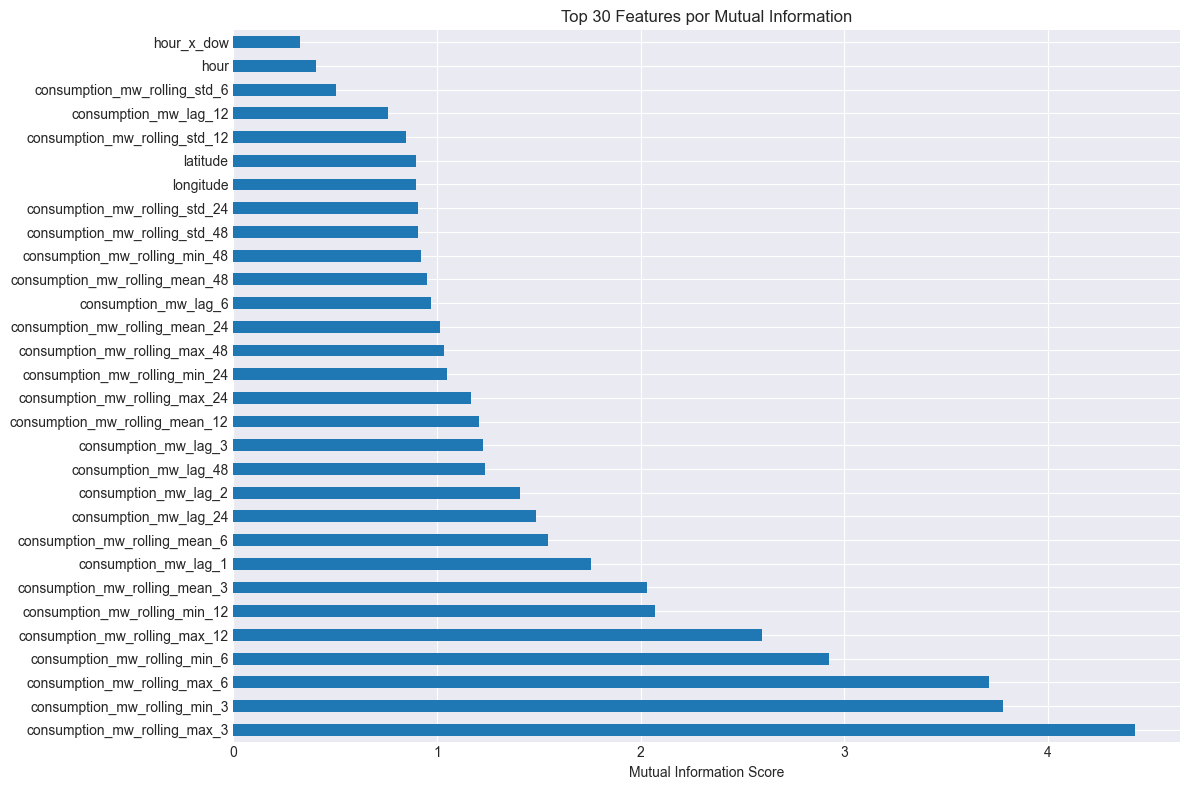

In [8]:
# 2. MUTUAL INFORMATION (captura relações não-lineares)
print("\n" + "="*80)
print("MUTUAL INFORMATION ANALYSIS")
print("="*80)
print("Calculando... (pode demorar alguns minutos)")

# Sample para acelerar (usar 10% dos dados)
df_sample = df_clean.sample(n=min(50000, len(df_clean)), random_state=42)

X_sample = df_sample[feature_cols]
y_sample = df_sample['consumption_mw']

# Calcular MI
mi_scores = mutual_info_regression(X_sample, y_sample, random_state=42)
mi_scores = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

print("\nTop 20 features por Mutual Information:")
print(mi_scores.head(20))

# Visualizar
fig, ax = plt.subplots(figsize=(12, 8))
mi_scores.head(30).plot(kind='barh', ax=ax)
ax.set_xlabel('Mutual Information Score')
ax.set_title('Top 30 Features por Mutual Information')
plt.tight_layout()
plt.show()

In [9]:
# 3. MULTICOLINEARIDADE (remover features altamente correlacionadas entre si)
print("\n" + "="*80)
print("ANÁLISE DE MULTICOLINEARIDADE")
print("="*80)

# Calcular matriz de correlação entre features
corr_matrix = df_clean[feature_cols].corr().abs()

# Encontrar pares com correlação > 0.95
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = []
for column in upper_triangle.columns:
    high_corr = upper_triangle[column][upper_triangle[column] > 0.95]
    if len(high_corr) > 0:
        for idx in high_corr.index:
            high_corr_pairs.append((column, idx, high_corr[idx]))

if high_corr_pairs:
    print(f"\n⚠️  Encontrados {len(high_corr_pairs)} pares de features com correlação > 0.95:")
    for feat1, feat2, corr in high_corr_pairs[:10]:
        print(f"  - {feat1} <-> {feat2}: {corr:.3f}")
else:
    print("\n✓ Não há features com multicolinearidade severa (> 0.95)")


ANÁLISE DE MULTICOLINEARIDADE

⚠️  Encontrados 133 pares de features com correlação > 0.95:
  - temperature_feels_like <-> temperature: 0.999
  - quarter <-> month: 0.971
  - day_of_year <-> month: 0.996
  - day_of_year <-> quarter: 0.968
  - week_of_year <-> month: 0.978
  - week_of_year <-> quarter: 0.952
  - week_of_year <-> day_of_year: 0.980
  - sin_day_of_year <-> sin_month: 0.955
  - cos_day_of_year <-> cos_month: 0.954
  - heat_index <-> temperature: 0.973


## 7. Selecionar Top Features

In [10]:
# Combinar scores de correlação e MI (normalizar e somar)
corr_norm = (correlations - correlations.min()) / (correlations.max() - correlations.min())
mi_norm = (mi_scores - mi_scores.min()) / (mi_scores.max() - mi_scores.min())

# Score combinado
combined_score = (corr_norm + mi_norm) / 2
combined_score = combined_score.sort_values(ascending=False)

print("\n" + "="*80)
print("SCORE COMBINADO (Correlação + Mutual Information)")
print("="*80)
print("\nTop 30 features:")
print(combined_score.head(30))

# Selecionar top N features
N_TOP_FEATURES = 50  # Usar top 50 features
top_features = combined_score.head(N_TOP_FEATURES).index.tolist()

print(f"\n✓ Selecionados {N_TOP_FEATURES} features para treino")


SCORE COMBINADO (Correlação + Mutual Information)

Top 30 features:
consumption_mw_rolling_max_3      0.997481
consumption_mw_rolling_min_3      0.926872
consumption_mw_rolling_max_6      0.892857
consumption_mw_rolling_min_6      0.819861
consumption_mw_rolling_max_12     0.736980
consumption_mw_rolling_mean_3     0.729216
consumption_mw_lag_1              0.695159
consumption_mw_rolling_min_12     0.693292
consumption_mw_rolling_mean_6     0.658641
consumption_mw_lag_24             0.658640
consumption_mw_lag_2              0.645316
consumption_mw_lag_48             0.620940
consumption_mw_lag_3              0.608561
consumption_mw_rolling_max_24     0.588507
consumption_mw_rolling_mean_12    0.586165
consumption_mw_rolling_mean_24    0.571671
consumption_mw_rolling_max_48     0.569511
consumption_mw_rolling_min_24     0.563605
consumption_mw_rolling_mean_48    0.560798
consumption_mw_rolling_std_24     0.549000
consumption_mw_rolling_std_48     0.548608
longitude                   

## 8. Preparar Dados para Treino

In [11]:
# Usar apenas top features
df_final = df_clean[top_features + ['consumption_mw']].copy()

# Split temporal
n = len(df_final)
train_end = int(0.70 * n)
val_end = int(0.85 * n)

X_train = df_final.iloc[:train_end][top_features].values
y_train = df_final.iloc[:train_end]['consumption_mw'].values

X_val = df_final.iloc[train_end:val_end][top_features].values
y_val = df_final.iloc[train_end:val_end]['consumption_mw'].values

X_test = df_final.iloc[val_end:][top_features].values
y_test = df_final.iloc[val_end:]['consumption_mw'].values

print("\n" + "="*80)
print("DATASETS FINAIS")
print("="*80)
print(f"Train: {len(X_train):,} amostras")
print(f"Val:   {len(X_val):,} amostras")
print(f"Test:  {len(X_test):,} amostras")
print(f"Features: {len(top_features)}")


DATASETS FINAIS
Train: 122,464 amostras
Val:   26,243 amostras
Test:  26,243 amostras
Features: 50


## 9. Treinar Modelo com Features Otimizadas

In [12]:
print("\n" + "="*80)
print("TREINAMENTO COM FEATURES AVANÇADAS")
print("="*80)

# XGBoost com features selecionadas
model_advanced = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

print("\nTreinando XGBoost...")
model_advanced.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Avaliar
evaluator = ModelEvaluator(output_dir='../data/models')

y_val_pred = model_advanced.predict(X_val)
val_metrics = evaluator.calculate_metrics(y_val, y_val_pred, prefix='val_')

y_test_pred = model_advanced.predict(X_test)
test_metrics = evaluator.calculate_metrics(y_test, y_test_pred, prefix='test_')

print("\n" + "="*80)
print("RESULTADOS COM FEATURE ENGINEERING AVANÇADO")
print("="*80)
print(f"\nValidação:")
print(f"  MAE:  {val_metrics['val_mae']:.2f} MW")
print(f"  RMSE: {val_metrics['val_rmse']:.2f} MW")
print(f"  MAPE: {val_metrics['val_mape']:.2f}%")
print(f"  R²:   {val_metrics['val_r2']:.4f}")

print(f"\nTeste:")
print(f"  MAE:  {test_metrics['test_mae']:.2f} MW")
print(f"  RMSE: {test_metrics['test_rmse']:.2f} MW")
print(f"  MAPE: {test_metrics['test_mape']:.2f}%")
print(f"  R²:   {test_metrics['test_r2']:.4f}")
print("="*80)


TREINAMENTO COM FEATURES AVANÇADAS

Treinando XGBoost...

RESULTADOS COM FEATURE ENGINEERING AVANÇADO

Validação:
  MAE:  9.93 MW
  RMSE: 18.44 MW
  MAPE: 0.88%
  R²:   0.9995

Teste:
  MAE:  10.45 MW
  RMSE: 19.83 MW
  MAPE: 0.85%
  R²:   0.9995


## 10. Feature Importance


Top 20 Features mais importantes (XGBoost):
                           feature  importance
5    consumption_mw_rolling_mean_3    0.709797
1     consumption_mw_rolling_min_3    0.224956
41                            hour    0.024138
0     consumption_mw_rolling_max_3    0.012014
29                        hour_cos    0.006716
35                      is_weekend    0.003748
2     consumption_mw_rolling_max_6    0.003407
30                        cos_hour    0.002421
3     consumption_mw_rolling_min_6    0.002311
6             consumption_mw_lag_1    0.001556
12            consumption_mw_lag_3    0.001144
4    consumption_mw_rolling_max_12    0.001114
10            consumption_mw_lag_2    0.001000
8    consumption_mw_rolling_mean_6    0.000617
25   consumption_mw_rolling_std_12    0.000571
27    consumption_mw_rolling_std_3    0.000490
14  consumption_mw_rolling_mean_12    0.000488
38                         day_sin    0.000445
34                      hour_x_dow    0.000394
23            c

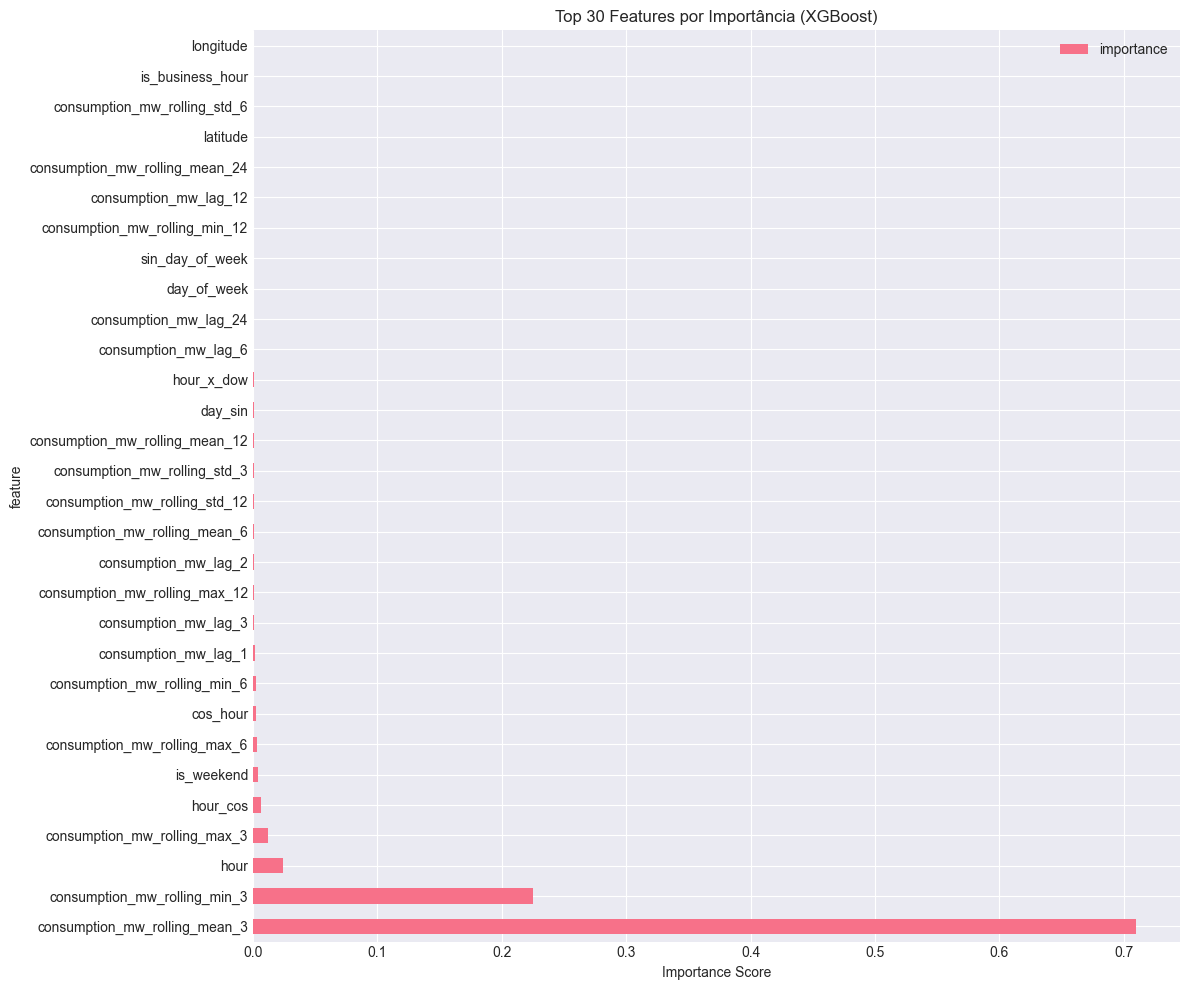

In [13]:
# Feature importance do XGBoost
importance = pd.DataFrame({
    'feature': top_features,
    'importance': model_advanced.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 20 Features mais importantes (XGBoost):")
print(importance.head(20))

# Visualizar
fig, ax = plt.subplots(figsize=(12, 10))
importance.head(30).plot(x='feature', y='importance', kind='barh', ax=ax)
ax.set_xlabel('Importance Score')
ax.set_title('Top 30 Features por Importância (XGBoost)')
plt.tight_layout()
plt.show()

## 11. Salvar Modelo e Features Otimizadas

In [14]:
output_dir = Path('../data/models')
output_dir.mkdir(parents=True, exist_ok=True)

# Salvar modelo avançado
model_path = output_dir / 'xgboost_advanced_features.pkl'
joblib.dump(model_advanced, model_path)
print(f"✓ Modelo salvo: {model_path}")

# Salvar lista de features selecionadas
features_path = output_dir / 'advanced_feature_names.txt'
with open(features_path, 'w') as f:
    for feat in top_features:
        f.write(f"{feat}\n")
print(f"✓ Features salvas: {features_path}")

# Salvar feature importance
importance_path = output_dir / 'feature_importance_advanced.csv'
importance.to_csv(importance_path, index=False)
print(f"✓ Feature importance salva: {importance_path}")

# Salvar metadata
import json

metadata = {
    'model_type': 'advanced_feature_engineering',
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'n_features': len(top_features),
    'n_samples_train': int(len(X_train)),
    'test_metrics': {
        'mae': float(test_metrics['test_mae']),
        'rmse': float(test_metrics['test_rmse']),
        'mape': float(test_metrics['test_mape']),
        'r2': float(test_metrics['test_r2'])
    },
    'feature_engineering': {
        'weather_derived': True,
        'trend_features': True,
        'feature_selection': 'correlation + mutual_information',
        'top_n_features': N_TOP_FEATURES
    }
}

metadata_path = output_dir / 'metadata_advanced.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Metadata salva: {metadata_path}")

✓ Modelo salvo: ..\data\models\xgboost_advanced_features.pkl
✓ Features salvas: ..\data\models\advanced_feature_names.txt
✓ Feature importance salva: ..\data\models\feature_importance_advanced.csv
✓ Metadata salva: ..\data\models\metadata_advanced.json


## 12. Comparação Final: Baseline vs Avançado

In [15]:
print("\n" + "="*80)
print("COMPARAÇÃO: MODELO BASELINE vs AVANÇADO")
print("="*80)

# Carregar metadata do modelo baseline (se existir)
baseline_path = output_dir / 'training_metadata.json'
if baseline_path.exists():
    with open(baseline_path, 'r') as f:
        baseline_meta = json.load(f)
    
    baseline_metrics = baseline_meta.get('test_metrics', {})
    
    comparison = pd.DataFrame({
        'Baseline': [
            baseline_metrics.get('mae', 0),
            baseline_metrics.get('rmse', 0),
            baseline_metrics.get('mape', 0),
            baseline_metrics.get('r2', 0)
        ],
        'Avançado': [
            test_metrics['test_mae'],
            test_metrics['test_rmse'],
            test_metrics['test_mape'],
            test_metrics['test_r2']
        ]
    }, index=['MAE (MW)', 'RMSE (MW)', 'MAPE (%)', 'R²'])
    
    comparison['Melhoria (%)'] = (
        (comparison['Baseline'] - comparison['Avançado']) / comparison['Baseline'] * 100
    )
    # R² é melhor quanto maior, então inverter
    comparison.loc['R²', 'Melhoria (%)'] = (
        (comparison.loc['R²', 'Avançado'] - comparison.loc['R²', 'Baseline']) / 
        comparison.loc['R²', 'Baseline'] * 100
    )
    
    print("\n", comparison.to_string())
    
    print("\n📈 Resumo:")
    if comparison.loc['MAPE (%)', 'Melhoria (%)'] > 0:
        print(f"   ✓ MAPE melhorou {comparison.loc['MAPE (%)', 'Melhoria (%)']:.2f}%")
    if comparison.loc['RMSE (MW)', 'Melhoria (%)'] > 0:
        print(f"   ✓ RMSE melhorou {comparison.loc['RMSE (MW)', 'Melhoria (%)']:.2f}%")
    if comparison.loc['R²', 'Melhoria (%)'] > 0:
        print(f"   ✓ R² melhorou {comparison.loc['R²', 'Melhoria (%)']:.4f}%")
else:
    print("\n⚠️  Modelo baseline não encontrado para comparação")
    print("Execute primeiro o notebook 02_model_training.ipynb")

print("\n" + "="*80)


COMPARAÇÃO: MODELO BASELINE vs AVANÇADO

             Baseline   Avançado  Melhoria (%)
MAE (MW)   10.648494  10.449563      1.868159
RMSE (MW)  20.248029  19.832716      2.051125
MAPE (%)    0.856918   0.845738      1.304679
R²          0.999454   0.999476      0.002221

📈 Resumo:
   ✓ MAPE melhorou 1.30%
   ✓ RMSE melhorou 2.05%
   ✓ R² melhorou 0.0022%



## 13. Conclusões e Próximos Passos

### ✅ O que fizemos:

1. **Features Meteorológicas Derivadas**
   - Heat Index, Wind Chill, Dew Point
   - Comfort Index e Effective Temperature
   - 9 features derivadas baseadas em fórmulas meteorológicas

2. **Features de Tendência**
   - Diferenças e variações (1ª e 2ª ordem)
   - Momentum e taxas de variação
   - Volatilidade e desvios da média

3. **Feature Selection Automático**
   - Análise de correlação com target
   - Mutual Information (relações não-lineares)
   - Detecção de multicolinearidade
   - Score combinado para seleção

4. **Modelo Otimizado**
   - Top 50 features mais relevantes
   - XGBoost treinado com features selecionadas

### 🎯 Próximos Passos:

1. **Hyperparameter Tuning** (Notebook 06)
   - Optuna para otimização automática
   - TimeSeriesSplit cross-validation

2. **Polynomial Features** (adicionar se necessário)
   - Interações de 2ª ordem entre top features
   - Aumentar complexidade do modelo

3. **SHAP Analysis**
   - Explicabilidade das previsões
   - Identificar padrões não óbvios